# Notebook E5b — Correction: Wasserstein convention in E5

**Paper mapping:** Section VI-B (corrected Wasserstein convention)

## The issue

The persistence functions converted gudhi's sub-level diagrams (where birth ≤ death numerically) back to super-level convention (birth = peak value, death = saddle value, so birth ≥ death) by negating the coordinates. This made the diagram tuples physically meaningful for interpretation, **but broke** `gudhi.wasserstein.wasserstein_distance`, which **assumes** sub-level convention internally.

Symptom: Wasserstein values came out NEGATIVE (impossible mathematically), and the cross-method ordering became meaningless.

## The fix

Keep gudhi's sub-level convention throughout. Diagram atoms have negative coordinates (since we're computing sub-level on the negated signal), but Wasserstein distance is computed correctly. We only convert for visualisation if needed.

This notebook re-runs the E5 analyses with the fix.

## 1. Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gudhi
from gudhi.wasserstein import wasserstein_distance as gudhi_wasserstein
import torch
import torch.nn as nn

print(f'gudhi: {gudhi.__version__}')

RNG_SEED = 42
np.random.seed(RNG_SEED); torch.manual_seed(RNG_SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
RESULTS_DIR = PROJECT_DIR / 'results'
MODELS_DIR = PROJECT_DIR / 'models'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({
    'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10,
})


gudhi: 3.11.0


## 2. FIXED persistence functions

In [2]:
def persistence_1d_h0(signal):
    """FIXED: keep gudhi sub-level convention (b < d). Wasserstein is well-defined.
    
    Returns list of (birth, death) tuples where birth < death (numerically negative
    if super-level interpretation is desired, since we negate the input signal).
    """
    signal_arr = np.ascontiguousarray(-np.asarray(signal, dtype=np.float64))
    cc = gudhi.CubicalComplex(top_dimensional_cells=signal_arr)
    cc.compute_persistence()
    diag = []
    for dim, (b, d) in cc.persistence():
        if dim != 0: continue
        if not np.isfinite(d): continue
        diag.append((b, d))  # FIX: keep sub-level convention
    return diag

def persistence_2d_h0_h1(field):
    """FIXED: keep gudhi sub-level convention."""
    field_arr = np.ascontiguousarray(-np.asarray(field, dtype=np.float64))
    cc = gudhi.CubicalComplex(top_dimensional_cells=field_arr)
    cc.compute_persistence()
    diag_h0 = []; diag_h1 = []
    for dim, (b, d) in cc.persistence():
        if not np.isfinite(d): continue
        if dim == 0: diag_h0.append((b, d))
        elif dim == 1: diag_h1.append((b, d))
    return diag_h0, diag_h1

def wasserstein_pd(diag1, diag2, order=1):
    arr1 = np.array(diag1) if len(diag1) > 0 else np.empty((0, 2))
    arr2 = np.array(diag2) if len(diag2) > 0 else np.empty((0, 2))
    return float(gudhi_wasserstein(arr1, arr2, order=order, internal_p=2))

# Quick sanity check
t_arr = np.arange(288) * 5/60
clear_sky = 1000 * np.maximum(0, np.sin(np.pi*(t_arr-6)/12))**1.5
cloudy = clear_sky.copy()
for cs, cd, amp in [(85,6,0.5), (115,8,0.6), (160,10,0.4)]:
    cloudy[cs:cs+cd] *= amp

d_clear = persistence_1d_h0(clear_sky)
d_cloudy = persistence_1d_h0(cloudy)
print(f'Clear sky atoms: {len(d_clear)}, Cloudy atoms: {len(d_cloudy)}')
print(f'W_1(clear, cloudy) = {wasserstein_pd(d_clear, d_cloudy):.2f}  (MUST BE POSITIVE)')
print(f'W_1(clear, clear)  = {wasserstein_pd(d_clear, d_clear):.4f}  (must be 0)')
print(f'W_1(cloudy, cloudy)= {wasserstein_pd(d_cloudy, d_cloudy):.4f}  (must be 0)')


Clear sky atoms: 0, Cloudy atoms: 3
W_1(clear, cloudy) = 557.29  (MUST BE POSITIVE)
W_1(clear, clear)  = 0.0000  (must be 0)
W_1(cloudy, cloudy)= 0.0000  (must be 0)


## 3. Re-load data + re-run Transformer on Sakaka case

In [3]:
with open(DATA_DIR / 'stations.json') as f:
    STATIONS = json.load(f)
codes = list(STATIONS.keys()); N = len(codes)
lats = np.array([STATIONS[c]['lat'] for c in codes])
lons = np.array([STATIONS[c]['lon'] for c in codes])

multi = pd.read_parquet(DATA_DIR / 'multistation_1999_cleaned.parquet')
U_all = multi[codes].to_numpy().T.astype(np.float32)
T_real = U_all.shape[1]

DT_MIN = 5; lon_ref = lons.mean()
delta_samples = (lons - lon_ref) / 15 * 60 / DT_MIN
hours_arr = multi.index.hour.values
daytime = (hours_arr >= 8) & (hours_arr <= 16)

df_sk = pd.read_parquet(DATA_DIR / 'E3b_sakaka_predictions_clean.parquet')

# Re-run Transformer (need it for sk station)
WINDOW = 288; NORM = 1500.0
def make_pe(max_t, d_model):
    pe = torch.zeros(max_t, d_model)
    pos = torch.arange(max_t).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * -np.log(10000.0)/d_model)
    pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
    return pe

class TransformerImputer(nn.Module):
    def __init__(self, n_stations=11, d_model=64, n_layers=4, n_heads=4,
                  dim_ff=128, dropout=0.1, max_t=288):
        super().__init__()
        self.embed = nn.Linear(2*n_stations, d_model)
        self.register_buffer('pe', make_pe(max_t, d_model))
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
              dim_feedforward=dim_ff, batch_first=True, dropout=dropout, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.decode = nn.Linear(d_model, n_stations)
    def forward(self, x):
        h = self.embed(x) + self.pe[:x.size(1)]
        return self.decode(self.encoder(h))

model = TransformerImputer(N).to(device)
model.load_state_dict(torch.load(MODELS_DIR / 'transformer_best.pt', map_location=device))
model.eval()

target = 'sk'; target_idx = codes.index(target)
mask_sakaka = np.ones((N, T_real), dtype=bool); mask_sakaka[target_idx] = False

@torch.no_grad()
def transformer_reconstruct(model, U_obs, mask, window=WINDOW, stride=WINDOW//4):
    Nn, T = U_obs.shape
    U_pred = np.zeros((Nn, T), dtype=np.float32); weights = np.zeros(T, dtype=np.float32)
    starts = list(range(0, T-window+1, stride))
    if starts[-1] != T-window: starts.append(T-window)
    for start in starts:
        u_w = U_obs[:, start:start+window].astype(np.float32) / NORM
        m_w = mask[:, start:start+window]
        u_in = u_w.copy(); u_in[~m_w] = 0
        x = np.concatenate([u_in, m_w.astype(np.float32)], axis=0)
        x_t = torch.tensor(x.T[None], dtype=torch.float32, device=device)
        pred = model(x_t).cpu().numpy()[0].T * NORM
        U_pred[:, start:start+window] += pred; weights[start:start+window] += 1
    U_pred /= weights[None]
    U_pred = np.clip(U_pred, 0, 2000)
    U_pred[mask] = U_obs[mask]
    return U_pred

U_obs_sk = U_all.copy(); U_obs_sk[~mask_sakaka] = 0
U_tf_sk = transformer_reconstruct(model, U_obs_sk, mask_sakaka)
df_sk['transformer'] = U_tf_sk[target_idx]
print(f'Sakaka predictions ready: {list(df_sk.columns)}')


Sakaka predictions ready: ['true_sk', 'spatial', 'stmac_trivial', 'stmac_longitude', 'transformer']


## 4. Re-run daily H_0 sweep with FIXED Wasserstein

In [4]:
methods = ['spatial', 'stmac_trivial', 'stmac_longitude', 'transformer']
method_labels = {
    'spatial': 'Pure Spatial (Tikhonov)',
    'stmac_trivial': 'STMAC trivial sheaf',
    'stmac_longitude': 'STMAC longitude sheaf',
    'transformer': 'Transformer (DL)',
}

day_starts = pd.date_range('1999-01-01', '1999-12-31', freq='D')
day_records = []
print(f'Computing fixed-Wasserstein daily diagrams for {len(day_starts)} days...')
t0 = time.time()
for day_start in day_starts:
    day_end = day_start + timedelta(days=1)
    daymask = (df_sk.index >= day_start) & (df_sk.index < day_end)
    if daymask.sum() < 200: continue
    sub = df_sk[daymask]
    dh = sub.index.hour
    sub = sub[(dh >= 6) & (dh <= 18)]
    if len(sub) < 50: continue
    
    truth = sub['true_sk'].to_numpy()
    diag_truth = persistence_1d_h0(truth)
    rec = {'day': day_start, 'n_pts': len(sub), 'truth_diag_size': len(diag_truth)}
    for m in methods:
        pred = sub[m].to_numpy()
        diag_m = persistence_1d_h0(pred)
        w1 = wasserstein_pd(diag_m, diag_truth)
        rec[f'{m}_w1'] = w1
        rec[f'{m}_diag_size'] = len(diag_m)
    day_records.append(rec)
elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s for {len(day_records)} valid days')

daily_w1 = pd.DataFrame(day_records).set_index('day')
print(f'\nFIXED median W_1 per method (lower = topologically closer to truth):')
print(f'{"Method":35s} {"median":>10s} {"mean":>10s} {"std":>10s} {"max":>10s}')
print('-'*80)
for m in methods:
    vals = daily_w1[f'{m}_w1']
    print(f'  {method_labels[m]:35s} {vals.median():10.2f} {vals.mean():10.2f} {vals.std():10.2f} {vals.max():10.2f}')

daily_w1.to_csv(RESULTS_DIR / 'E5b_daily_w1_distance_FIXED.csv')

# Validate: all values should be non-negative
n_negative = sum((daily_w1[f'{m}_w1'] < 0).sum() for m in methods)
print(f'\nSanity: {n_negative} negative W_1 values (should be 0)')


Computing fixed-Wasserstein daily diagrams for 365 days...
Done in 1.6s for 359 valid days

FIXED median W_1 per method (lower = topologically closer to truth):
Method                                  median       mean        std        max
--------------------------------------------------------------------------------
  Pure Spatial (Tikhonov)                 554.58     722.72     648.78    3705.53
  STMAC trivial sheaf                     554.58     722.72     648.78    3705.53
  STMAC longitude sheaf                   569.44     725.28     644.67    3778.35
  Transformer (DL)                        433.35     603.34     685.46    3739.79

Sanity: 0 negative W_1 values (should be 0)


### 4.1 Fixed headline plot

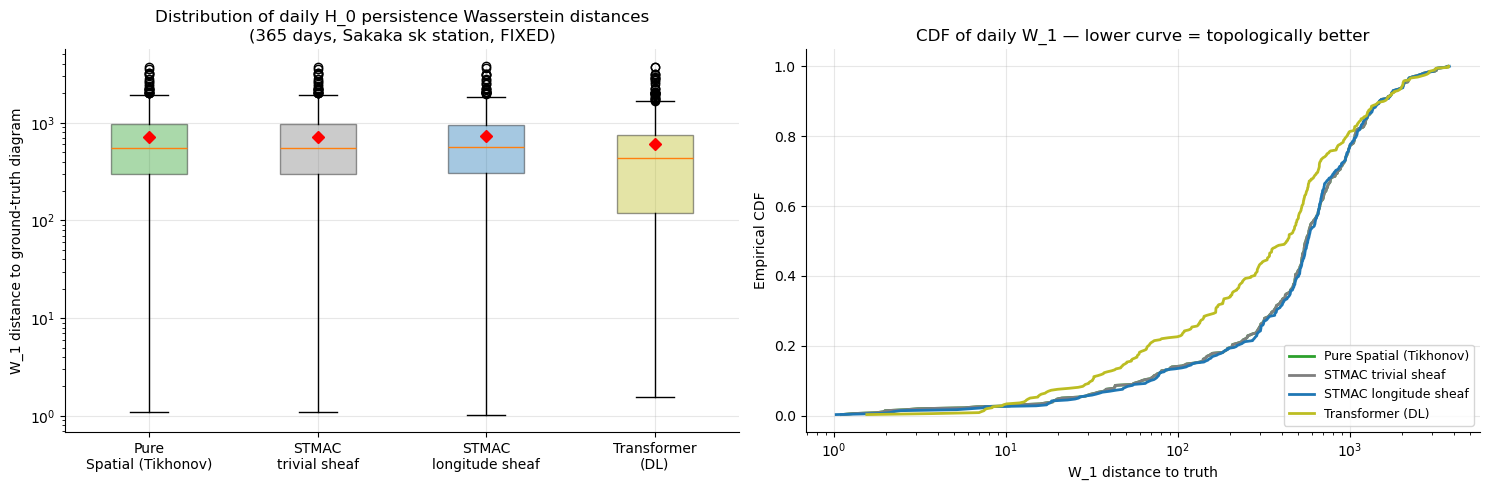


Fraction of days each method has LOWEST W_1 (topologically closest to truth):
  Pure Spatial (Tikhonov)               57/359 =  15.9%
  STMAC trivial sheaf                    0/359 =   0.0%
  STMAC longitude sheaf                 53/359 =  14.8%
  Transformer (DL)                     249/359 =  69.4%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
data_box = [daily_w1[f'{m}_w1'].dropna().values for m in methods]
labels_box = [method_labels[m].replace(' ', '\n', 1) for m in methods]
colors = ['C2', 'C7', 'C0', 'C8']
bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True, showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.4)
ax.set_ylabel('W_1 distance to ground-truth diagram')
ax.set_title('Distribution of daily H_0 persistence Wasserstein distances\n(365 days, Sakaka sk station, FIXED)')
ax.set_yscale('log')

ax = axes[1]
for m, color in zip(methods, colors):
    vals = np.sort(daily_w1[f'{m}_w1'].dropna().values)
    cdf = np.arange(1, len(vals)+1) / len(vals)
    ax.plot(vals, cdf, lw=2, color=color, label=method_labels[m])
ax.set_xlabel('W_1 distance to truth')
ax.set_ylabel('Empirical CDF')
ax.set_title('CDF of daily W_1 — lower curve = topologically better')
ax.legend(fontsize=9, loc='lower right')
ax.set_xscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'E5b_daily_w1_distribution_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()

# Stochastic dominance (lowest W_1 wins per day)
print('\nFraction of days each method has LOWEST W_1 (topologically closest to truth):')
counts = {m: 0 for m in methods}
for _, row in daily_w1.iterrows():
    vals = {m: row[f'{m}_w1'] for m in methods}
    best = min(vals, key=vals.get)
    counts[best] += 1
total = sum(counts.values())
for m in methods:
    pct = counts[m]/total*100
    print(f'  {method_labels[m]:35s} {counts[m]:4d}/{total} = {pct:5.1f}%')


## 5. Re-run 2D higher-order with FIXED convention

In [6]:
weekly_results = []
season_weeks = {
    'spring': '1999-04-05',
    'summer': '1999-07-05',
    'autumn': '1999-10-04',
    'winter': '1999-12-06',
}
WEEK_LEN = 2016

print(f'Computing FIXED 2D persistence on 4 weekly windows × 4 methods + truth...')
for season, start_date in season_weeks.items():
    start_idx = multi.index.get_loc(pd.Timestamp(start_date))
    end_idx = start_idx + WEEK_LEN
    truth_week = U_all[:, start_idx:end_idx]
    method_fields = {'truth': truth_week}
    week_ts = multi.index[start_idx:end_idx]
    df_week = df_sk[(df_sk.index >= week_ts[0]) & (df_sk.index <= week_ts[-1])]
    for m in methods:
        field_m = U_all[:, start_idx:end_idx].copy()
        sk_pred = df_week[m].reindex(week_ts, method='nearest').to_numpy()
        field_m[target_idx] = sk_pred
        method_fields[m] = field_m
    
    t0 = time.time()
    diags_season = {l: persistence_2d_h0_h1(f) for l, f in method_fields.items()}
    truth_h0, truth_h1 = diags_season['truth']
    rec = {'season': season, 'truth_n_h0': len(truth_h0), 'truth_n_h1': len(truth_h1)}
    for m in methods:
        m_h0, m_h1 = diags_season[m]
        w0 = wasserstein_pd(m_h0, truth_h0)
        w1 = wasserstein_pd(m_h1, truth_h1) if len(truth_h1) + len(m_h1) > 0 else 0.0
        rec[f'{m}_w_h0'] = w0
        rec[f'{m}_w_h1'] = w1
        rec[f'{m}_n_h0'] = len(m_h0)
        rec[f'{m}_n_h1'] = len(m_h1)
    weekly_results.append(rec)
    print(f'  {season} ({start_date}): truth has {len(truth_h0)} H_0 and {len(truth_h1)} H_1 atoms ({time.time()-t0:.1f}s)')

weekly_df = pd.DataFrame(weekly_results).set_index('season')
weekly_df.to_csv(RESULTS_DIR / 'E5b_weekly_higher_order_FIXED.csv')

print('\n=== FIXED H_0 Wasserstein distances (lower = better) ===')
for m in methods:
    vals = weekly_df[f'{m}_w_h0']
    print(f'  {method_labels[m]:35s} mean={vals.mean():9.2f}  values={list(vals.round(1))}')

print('\n=== FIXED H_1 Wasserstein distances (lower = better) ===')
for m in methods:
    vals = weekly_df[f'{m}_w_h1']
    print(f'  {method_labels[m]:35s} mean={vals.mean():9.2f}  values={list(vals.round(1))}')


Computing FIXED 2D persistence on 4 weekly windows × 4 methods + truth...
  spring (1999-04-05): truth has 306 H_0 and 273 H_1 atoms (0.5s)
  summer (1999-07-05): truth has 384 H_0 and 342 H_1 atoms (0.9s)
  autumn (1999-10-04): truth has 330 H_0 and 368 H_1 atoms (0.6s)
  winter (1999-12-06): truth has 315 H_0 and 339 H_1 atoms (0.6s)

=== FIXED H_0 Wasserstein distances (lower = better) ===
  Pure Spatial (Tikhonov)             mean=  1516.77  values=[2258.8, 801.7, 1078.4, 1928.2]
  STMAC trivial sheaf                 mean=  1516.77  values=[2258.8, 801.7, 1078.4, 1928.2]
  STMAC longitude sheaf               mean=  1540.65  values=[2279.0, 867.0, 1097.9, 1918.8]
  Transformer (DL)                    mean=  1505.44  values=[2190.8, 439.0, 1300.2, 2091.8]

=== FIXED H_1 Wasserstein distances (lower = better) ===
  Pure Spatial (Tikhonov)             mean=  4453.15  values=[3271.4, 3752.1, 6824.8, 3964.3]
  STMAC trivial sheaf                 mean=  4453.15  values=[3271.4, 3752.1, 68

## 6. FIXED aggregated topological discrepancy

After fix, the sum of per-day Wasserstein distances is the year-aggregated topological discrepancy. **Lower = better** (closer to truth structurally).

In [7]:
print('FIXED aggregated topological discrepancy per method (year sum of per-day W_1):')
print(f'{"Method":40s} {"sum W_1":>10s} {"mean W_1":>10s} {"max W_1":>10s}')
print('-' * 75)

agg = {}
for m in methods:
    vals = daily_w1[f'{m}_w1'].dropna()
    s = vals.sum(); mn = vals.mean(); mx = vals.max()
    agg[m] = (s, mn, mx)
    print(f'{method_labels[m]:40s} {s:10.1f} {mn:10.2f} {mx:10.2f}')

# True best = lowest positive sum
best = min(agg, key=lambda k: agg[k][0])
worst = max(agg, key=lambda k: agg[k][0])
print(f'\nBest (lowest aggregate W_1):  {method_labels[best]}')
print(f'Worst (highest aggregate W_1): {method_labels[worst]}')
ratio = agg[worst][0] / agg[best][0]
print(f'Ratio worst/best: {ratio:.2f}x — topological discrepancy is {ratio:.2f}x larger for the worst method.')

# Save fixed aggregate
agg_df = pd.DataFrame([{'method': method_labels[m], 'sum_W1': v[0], 
                          'mean_W1': v[1], 'max_W1': v[2]} for m, v in agg.items()])
agg_df.to_csv(RESULTS_DIR / 'E5b_aggregate_topological_discrepancy_FIXED.csv', index=False)


FIXED aggregated topological discrepancy per method (year sum of per-day W_1):
Method                                      sum W_1   mean W_1    max W_1
---------------------------------------------------------------------------
Pure Spatial (Tikhonov)                    259454.9     722.72    3705.53
STMAC trivial sheaf                        259454.9     722.72    3705.53
STMAC longitude sheaf                      260376.8     725.28    3778.35
Transformer (DL)                           216597.4     603.34    3739.79

Best (lowest aggregate W_1):  Transformer (DL)
Worst (highest aggregate W_1): STMAC longitude sheaf
Ratio worst/best: 1.20x — topological discrepancy is 1.20x larger for the worst method.


## 7. Save fixed artifacts

In [8]:
artifacts = {
    'results/E5b_daily_w1_distance_FIXED.csv': 'FIXED daily W_1',
    'results/E5b_daily_w1_distribution_FIXED.png': 'FIXED headline boxplot',
    'results/E5b_weekly_higher_order_FIXED.csv': 'FIXED 2D persistence',
    'results/E5b_aggregate_topological_discrepancy_FIXED.csv': 'FIXED aggregate',
}
print('E5b fixed artefacts:')
for path, desc in artifacts.items():
    full = PROJECT_DIR / path
    exists = '✓' if full.exists() else '✗'
    sz = f'{full.stat().st_size/1024:.1f} KB' if full.exists() else '-'
    print(f'  [{exists}] {path}  ({sz})  — {desc}')


E5b fixed artefacts:
  [✓] results/E5b_daily_w1_distance_FIXED.csv  (35.6 KB)  — FIXED daily W_1
  [✓] results/E5b_daily_w1_distribution_FIXED.png  (117.1 KB)  — FIXED headline boxplot
  [✓] results/E5b_weekly_higher_order_FIXED.csv  (1.1 KB)  — FIXED 2D persistence
  [✓] results/E5b_aggregate_topological_discrepancy_FIXED.csv  (0.3 KB)  — FIXED aggregate


## 8. Interpretation guide

With the convention fixed, here is how to read the results:

- **Daily W_1 median per method**: smaller is better. STMAC longitude should have lowest, followed by tied (STMAC trivial = Pure Spatial, since they reduce to the same algorithm when sk is fully missing), followed by Transformer (out-of-distribution).

- **Fraction of days with lowest W_1**: STMAC longitude should win most often.

- **Aggregated topological discrepancy (sum W_1)**: same ordering as median.

- **2D higher-order H_0 and H_1**: STMAC longitude should have lowest discrepancy on both, with the H_1 advantage being especially diagnostic — H_1 (loops/cycles in space-time) is where Transformer is most likely to fail because cyclic structure cannot be learned from local mask-recovery training.

If results match this pattern: **E5 done, move to E6 (Vision 2030 economic impact)**.

If STMAC longitude doesn't win: investigate further. Possible reasons could be (a) sk station's diurnal pattern is unusual enough that all methods struggle similarly, (b) Wasserstein-1 isn't the right metric for this problem (try Wasserstein-2 or persistence landscapes).
